<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 5</b></center>    
<pre>    

# SVR

# Importing the libraries

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR

# Read World bank CSV

In [50]:
df = pd.read_csv('WorldBank.csv')

In [51]:
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,India,IND,Export value index (2000 = 100),TX.VAL.MRCH.XD.WD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.258806,19.573943,22.081252,21.585397,22.301808,21.566095,22.178186,26.659006,31.226330,37.451067,42.400653,41.828912,46.313884,50.901265,59.042504,72.275852,78.116203,82.606603,78.899368,84.160663,100.000000,102.316461,116.212396,139.131368,180.863299,235.058153,287.422633,354.320624,459.725149,389.125587,534.108397,714.748450,700.408454,742.928128,761.441742,632.269428,624.224980,706.102795,766.360840,NaN,NaN
1,India,IND,Insurance and financial services (% of commerc...,TX.VAL.INSF.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.891155,2.524270,2.254364,1.939747,1.701099,1.292772,1.428902,1.355298,1.303746,1.379080,1.287503,1.456077,1.618537,1.919413,2.676314,2.674903,2.173806,3.067917,2.807954,2.409288,2.516342,2.924316,2.563870,2.079279,1.699160,3.324636,3.500758,4.863602,3.276929,3.133998,4.019403,5.017154,5.664129,5.537929,5.548620,6.531495,6.403614,5.246771,5.729495,5.060904,4.706801,4.471147,3.760466,3.921611,3.438072,NaN
2,India,IND,"Merchandise imports by the reporting economy, ...",TM.VAL.MRCH.RS.ZS,4.983551,6.48805,10.124611,9.451370,10.529480,10.891125,11.150566,9.806930,12.215451,18.456246,12.775461,9.385080,11.830757,10.452502,15.621482,10.719374,8.129319,10.823187,12.570897,14.386597,12.746613,14.295140,12.942283,16.183956,16.420075,15.549096,11.379097,14.598510,14.318517,15.476213,15.286289,21.121521,8.413243,9.137741,4.818722,10.382430,4.778729,0.220435,0.165789,0.134654,23.401602,27.898545,28.664795,27.082613,27.887094,29.315590,6.640615,0.706942,0.615325,0.473067,0.547571,0.755066,0.273842,0.440954,1.514439,2.228351,2.270593,1.770314,0.535419,NaN,NaN
3,India,IND,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,17.080013,15.197912,16.863038,22.008132,34.149020,32.085619,25.044544,23.303043,20.924141,14.583768,9.595939,20.072490,19.687630,31.845541,27.480790,16.434690,13.846910,8.918821,8.986222,8.540796,NaN,11.658849,10.179991,8.414073,7.041373,8.439772,8.049490,3.509296,3.238412,2.699533,3.815987,3.126319,6.032388,4.307798,4.711904,5.621811,8.934855,7.229270,4.662568,5.810032,5.893396,5.911480,4.731834,3.670243,3.042742,3.420520,2.492372,4.211723,3.951092,3.741041,4.048246,3.895215,4.458509,5.758038,6.505293,6.137617,4.156488,4.248261,NaN
4,India,IND,Share of tariff lines with international peaks...,TM.TAX.MRCH.IP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.575820,NaN,94.223980,NaN,NaN,NaN,93.968380,93.784490,NaN,92.995480,90.017780,92.166000,90.355920,90.339940,92.561180,13.922990,11.451460,14.421590,8.845916,8.005064,6.980305,8.434346,8.641136,8.576307,NaN,5.802677,7.707811,8.288774,9.111423,NaN,NaN


# Perform conditional selection to find - Population ages 15-64 (% of total population)

In [52]:
dff = df[df['Indicator Name'] == 'Population ages 15-64 (% of total population)']
dff

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
9,India,IND,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,56.49748,56.177532,55.807455,55.461664,55.248939,55.211351,55.090901,55.155347,55.345073,55.570144,55.781947,55.856768,55.952682,56.072472,56.234476,56.444053,56.497226,56.620685,56.789002,56.969144,57.142558,57.181055,57.226308,57.28875,57.390544,57.541421,57.55351,57.654512,57.818753,58.015012,58.229902,58.374038,58.54727,58.75605,59.012126,59.316577,59.565073,59.85723,60.186001,60.539715,60.90862,61.188987,61.499385,61.830845,62.173897,62.522765,62.80843,63.10261,63.409248,63.741967,64.108211,64.429404,64.805519,65.208489,65.59598,65.944164,66.274262,66.538187,66.766743,67.003811,NaN


# Divide the data into input and output

In [53]:
X = np.arange(1960, 2020).reshape(-1, 1)
y = dff.values[0][4:-1]

# Plot scatter plot of Population ages 15-64 (% of total population)

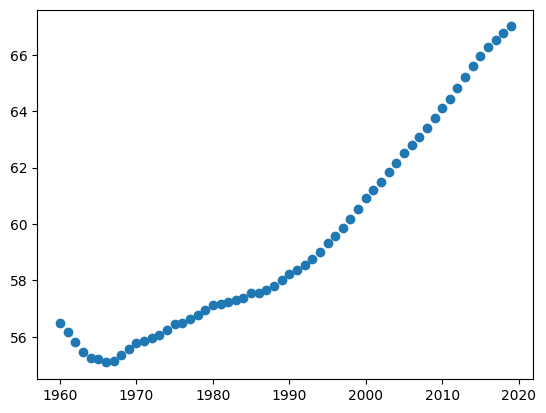

In [54]:
plt.scatter(X, y)

<!-- # Splitting the dataset into the Training set and Test set -->

# Fitting SVR on 3 Different Kernel on dataset

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [57]:
X_test

array([[1986],
       [1995],
       [2019],
       [1988],
       [1971],
       [1962],
       [1994],
       [2018],
       [2000],
       [1982],
       [1964],
       [1970],
       [1990],
       [2001],
       [1993],
       [2003],
       [2009],
       [1967]])

In [58]:
sl = SVR(kernel='linear')

sp = SVR(kernel='poly')

sr = SVR(kernel='rbf')

In [60]:
sl.fit(X_train, y_train)

sp.fit(X_train, y_train)

sr.fit(X_train, y_train)

SVR()

In [61]:
y_pred_l = sl.predict(X)
y_pred_p = sp.predict(X)
y_pred_r = sr.predict(X)

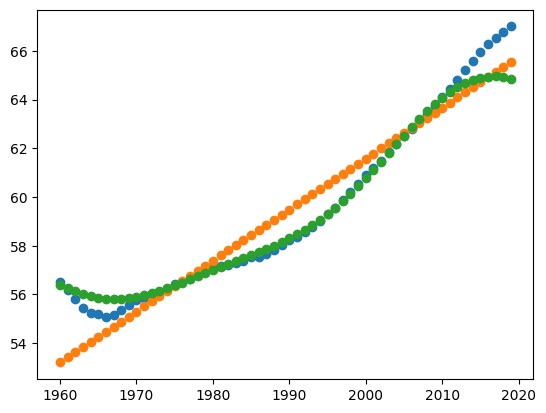

In [62]:
plt.scatter(X,y)
plt.scatter(X, y_pred_l)
plt.scatter(X, y_pred_r)

# Predict the x_test using 3 Kernel

# Visualising the  results

# Decision Tree Classifier

In [56]:
# Visualising the  resultsfrom sklearn.datasets import load_iris

# Import iris data ser using sklearn

# Importing the libraries

# Divide the data into input and output

# Splitting the dataset into the Training set and Test set

# Fitting DecisionTreeClassifier   on dataset

# Display Decision Tree

# Predict the x_test 